In [1]:
import matplotlib.pyplot as plt
import pyproj as proj
import cartopy.crs as ccrs
from cartopy import config
import cartopy.feature as cfeature
from cartopy.vector_transform import vector_scalar_to_grid
from matplotlib.axes import Axes
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()
import metpy
import pint
import metpy.calc as mpcalc
from metpy.units import units
from metpy.interpolate import log_interpolate_1d
#from metpy.plots import add_metpy_logo, add_timestamp
#import pyke
import iris
import numpy as np
import iris.plot as iplt
import iris.util
import iris.quickplot as qplt
import iris.analysis.cartography
from iris.analysis.cartography import rotate_pole, rotate_winds
import iris.coord_systems
import scipy as sp
from scipy.interpolate import RectBivariateSpline
from scipy.interpolate import interp2d
import xarray as xr
#from lagranto import Tra
import math
#from GEOS5functions import *
import datetime
import ssl
ssl._create_default_https_context = ssl._create_unverified_context


/home/modares/.virtualenvs/myenv_trillium/lib/python3.11/site-packages/pyproj/__init__.py:91: UserWarning: Valid PROJ data directory not found. Either set the path using the environmental variable PROJ_DATA (PROJ 9.1+) | PROJ_LIB (PROJ<9.1) or with `pyproj.datadir.set_data_dir`.
  warnings.warn(str(err))


In [4]:
%run GEOS5functions.py

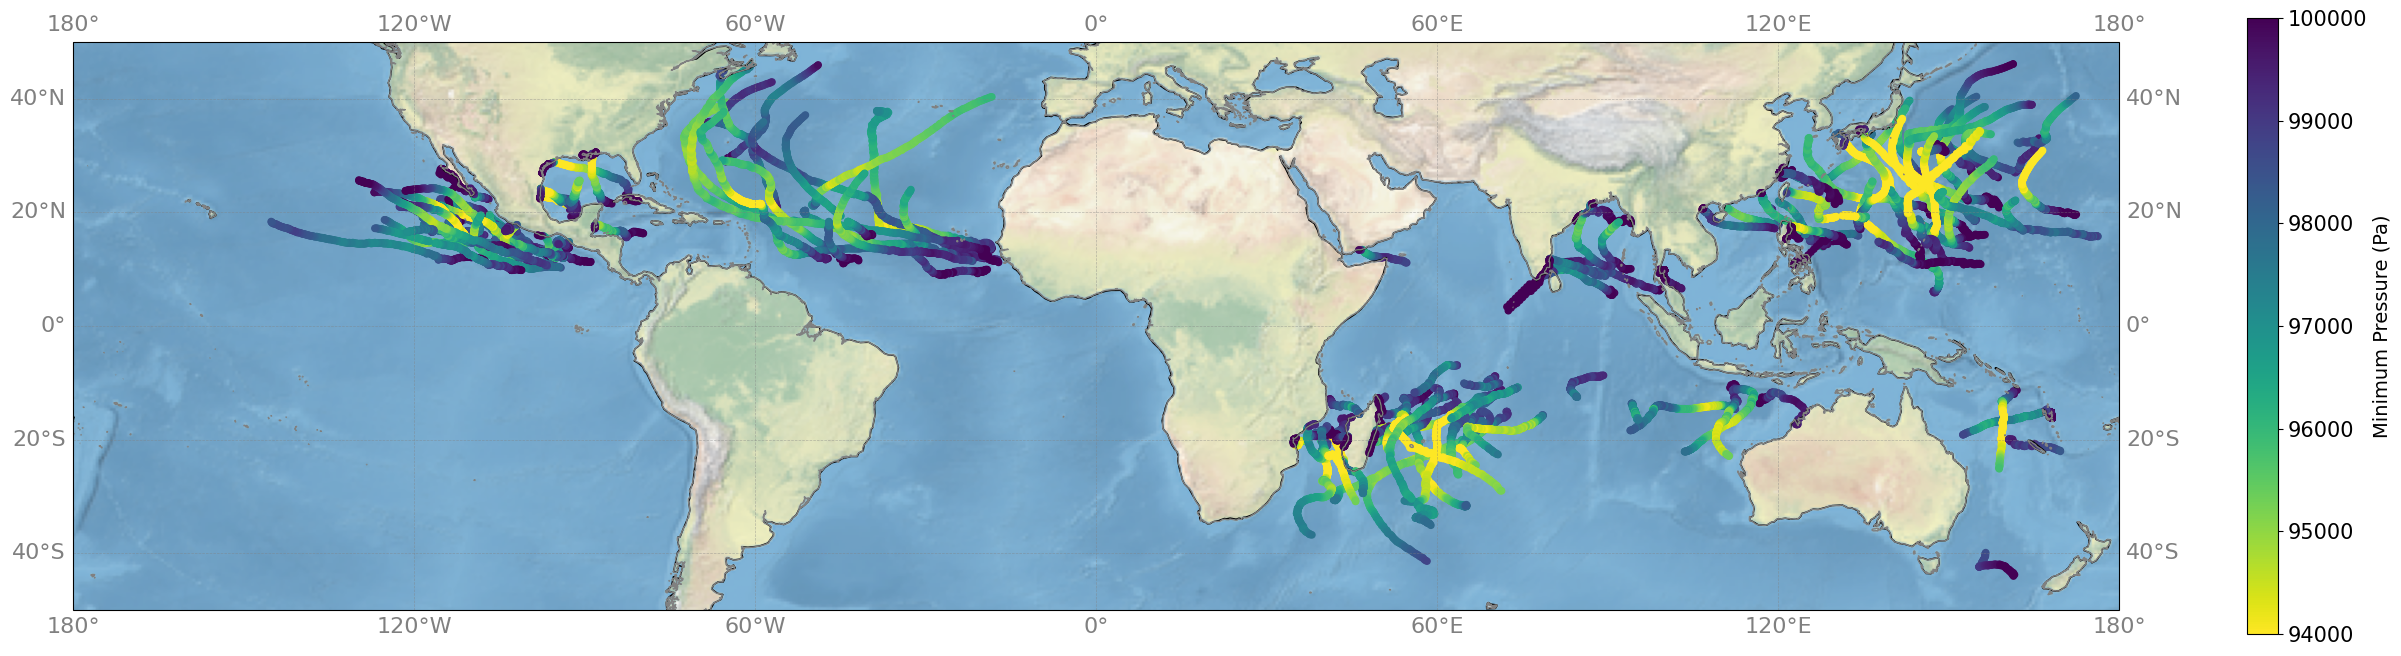

In [11]:
from scipy.ndimage import gaussian_filter
from matplotlib.ticker import ScalarFormatter
import matplotlib as mpl
mpl.rcParams.update({'font.size': 15})  

fig = plt.figure(figsize=(33,10))
crs0 = ccrs.PlateCarree(central_longitude=0)
ax = fig.add_subplot(1, 1, 1, projection=crs0)
#ax.set_extent([lon[0], lon[-1], lat[0], lat[-1]], crs=crs0)

#####

ax.set_extent([-180, 180, -50, 50], crs=crs0)
ax.stock_img()
#ax.add_feature(cfeature.LAKES, alpha=0.5)
#ax.add_feature(cfeature.OCEAN)

#ax.add_feature(cfeature.LAND)
#####

ax.coastlines()
ax.coastlines('50m', color='gray',edgecolor='white')
gl = ax.gridlines(crs=crs0, draw_labels=True,
          linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.xlabel_style = {'size':16,'color':'gray'}
gl.ylabel_style = {'size':16,'color':'gray'}

#h1 = ax.pcolormesh(lon,lat,so4,vmin=0,vmax=1e-9,cmap='Blues')
#ax.contour(lon,lat,np.sqrt(u**2 + v**2 + w**2),[20,30,40,50],colors='c')
testvec = [95]

coastal = np.concatenate([
    [1, 11, 20, 22, 24],
    np.arange(26, 36),
    [37, 42, 44],
    np.arange(45, 54),
    [55, 59, 60, 62, 64, 65, 67, 68, 71],
    np.arange(75, 91),
    [98],
    np.arange(100, 108),
    np.arange(114, 125),
    np.arange(125, 133),
    [134, 135, 136, 141, 148],
    np.arange(152, 157),
    np.arange(159, 160),
    [161]
])
ocean = np.concatenate([
    [0],
    np.arange(2, 11),
    np.arange(12, 20),
    [21, 23, 25, 36, 38, 39, 40, 41, 43, 57, 61, 63, 66, 69, 70, 72, 73, 74, 91, 93, 94, 96, 97],
    np.arange(108, 111),
    np.arange(112, 114),
    [ 133, 137, 165, 166]
])

all_of_all =  np.concatenate([coastal, ocean])

# discarded: 

# Initialize arrays to hold all points and pressures
all_minplon = []
all_minplat = []
all_minpres = []

for i in all_of_all:
    stormname = stormlist[1][i]
    npzfile = np.load(stormname[0:9] + '.npz')
    all_minplon.append(npzfile['minplon'])
    all_minplat.append(npzfile['minplat'])
    all_minpres.append(npzfile['minpres'])

# Concatenate all data for plotting
all_minplon = np.concatenate(all_minplon)
all_minplat = np.concatenate(all_minplat)
all_minpres = np.concatenate(all_minpres)

# Plot all points at once
sc = ax.scatter(all_minplon, all_minplat, c=all_minpres, vmin=94000, vmax=100000,
                s=20, cmap='viridis_r', transform=crs0)

# Add colorbar
cbar = plt.colorbar(sc, ax=ax, orientation="vertical", shrink=0.8, pad=0.05)
cbar.set_label('Minimum Pressure (Pa)', fontsize=14)




#plt.savefig('GEOS5NatureRun2yearsofTCs.png', bbox_inches='tight')
